# Applying the Rosen-Roback Model to US Data

In the previous notebook, we built a Rosen-Roback spatial equilibrium model from first principles. Now we apply it to real US data.

**Data sources:**
- Hsieh-Moretti (2019) replication data: wages, employment, housing prices by MSA
- Saiz (2010): housing supply elasticities by MSA

**What we'll do:**
1. Explore the data - what do US metros look like?
2. Validate Rosen-Roback predictions in the data
3. Calibrate productivity from wages and prices
4. Run counterfactual: what if constrained cities had elastic supply?
5. Estimate GDP cost of housing constraints

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Paths
DATA_DIR = Path('../data/raw/us/saiz')

## Part 1: Loading and Exploring the Data

In [2]:
# Load Hsieh-Moretti data
hm_raw = pd.read_csv(DATA_DIR / 'hsieh_moretti_data.csv')
print(f"Loaded {len(hm_raw)} MSAs with {hm_raw.shape[1]} variables")

# Extract key variables for 2009 (most recent year)
df = pd.DataFrame({
    'msa_code': hm_raw['msa'],
    'name': hm_raw['name_msa'],
    'wage': hm_raw['wage2009'],
    'employment': hm_raw['emp2009'],
    'housing_price': hm_raw['ap2009'],  # Aggregate housing price
    'elasticity': hm_raw['elasticity'],
    'wrluri': hm_raw['WRLURI'],  # Regulation index
    'land_unavailable': hm_raw['unaval'],  # Geographic constraints
    'population': hm_raw['populat_saiz'],
})

# Also get 1964 data for comparison
df['wage_1964'] = hm_raw['wage1964']
df['employment_1964'] = hm_raw['emp1964']

# Drop rows with missing elasticity
df = df[df['elasticity'].notna()].copy()
print(f"MSAs with elasticity data: {len(df)}")

df.head()

Loaded 220 MSAs with 457 variables
MSAs with elasticity data: 201


,msa_code,name,wage,employment,housing_price,elasticity,wrluri,land_unavailable,population,wage_1964,employment_1964
0,40.0,PUERTO RICO,22813.173828,52445.5,1.196463e+06,3.094851,0.100831,0.019526,126441.0,21822.635,22576.5
1,80.0,"AKRON, OH",30462.945312,284920.5,8.676943e+06,2.585493,0.067560,0.064532,695781.0,31756.156,174196.5
2,120.0,"ALBANY, GA",23790.589844,44577.5,1.060384e+06,3.392287,-0.498107,0.127298,120855.0,19949.447,17150.0
3,160.0,"ALBANY-SCHENECTADY-TROY, NY",30582.246094,348191.0,1.064737e+07,1.700388,-0.091784,0.233302,876129.0,28326.705,188829.5
4,200.0,"ALBUQUERQUE, NM",28069.746094,295323.5,8.288306e+06,2.112380,0.373471,0.116333,714554.0,26254.092,69621.5


In [3]:
# Summary statistics
print("Summary Statistics (2009)")
print("=" * 60)
for col in ['wage', 'employment', 'housing_price', 'elasticity']:
    print(f"{col:20} min={df[col].min():12,.0f}  median={df[col].median():12,.0f}  max={df[col].max():12,.0f}")

Summary Statistics (2009)
wage                 min=      18,337  median=      28,289  max=      59,661
employment           min=      30,880  median=     168,780  max=   3,852,599
housing_price        min=     685,952  median=   4,592,347  max= 215,154,786
elasticity           min=           1  median=           2  max=           8


In [4]:
# Identify key metros
key_metros = [
    'NEW YORK',
    'LOS ANGELES',
    'SAN FRANCISCO',
    'SAN JOSE',
    'CHICAGO',
    'HOUSTON',
    'DALLAS',
    'BOSTON',
    'SEATTLE',
    'DETROIT',
]

def find_metro(name_part):
    """Find metro by partial name match."""
    matches = df[df['name'].str.contains(name_part, case=False, na=False)]
    if len(matches) > 0:
        return matches.iloc[0]
    return None

print("Key Metro Areas")
print("=" * 90)
print(f"{'Metro':<30} {'Wage':>10} {'Emp (000s)':>12} {'Price':>12} {'Elasticity':>12}")
print("-" * 90)
for metro in key_metros:
    row = find_metro(metro)
    if row is not None:
        print(f"{row['name'][:30]:<30} ${row['wage']:>9,.0f} {row['employment']/1000:>12,.0f} ${row['housing_price']/1e6:>10.1f}M {row['elasticity']:>12.2f}")

Key Metro Areas
Metro                                Wage   Emp (000s)        Price   Elasticity
------------------------------------------------------------------------------------------
NEW YORK-NEWARK, NY-NJ-PA      $   55,795        3,853 $     215.2M         0.76
LOS ANGELES-LONG BEACH, CA     $   37,159        3,807 $     141.4M         0.63
SAN FRANCISCO, CA              $   53,773          959 $      51.6M         0.66
SAN JOSE, CA                   $   59,661          885 $      52.8M         0.76
CHICAGO, IL                    $   39,225        3,770 $     147.9M         0.81
HOUSTON, TX                    $   41,211        2,089 $      86.1M         2.30
DALLAS, TX                     $   38,304        1,850 $      70.9M         2.18
BOSTON-WORCESTER-LAWRENCE-LOWE $   41,379        3,022 $     125.0M         0.86
SEATTLE-BELLEVUE-EVERETT, WA   $   42,382        1,303 $      55.2M         0.88
DETROIT, MI                    $   35,685        1,627 $      58.1M         1.24


### Key Observation

Notice the **inverse relationship** between wages/prices and elasticity:
- **Low elasticity** (constrained): NYC, LA, SF, San Jose - high wages, high prices
- **High elasticity** (unconstrained): Houston, Dallas - moderate wages, lower prices

This is exactly what Rosen-Roback predicts: productive places bid up land prices, and if supply can't respond, prices spike.

## Part 2: Visualizing Rosen-Roback Relationships

In [5]:
# Calculate rent proxy (housing price per worker)
df['rent_proxy'] = df['housing_price'] / df['employment']

# Log transformations for visualization
df['log_wage'] = np.log(df['wage'])
df['log_rent'] = np.log(df['rent_proxy'])
df['log_emp'] = np.log(df['employment'])

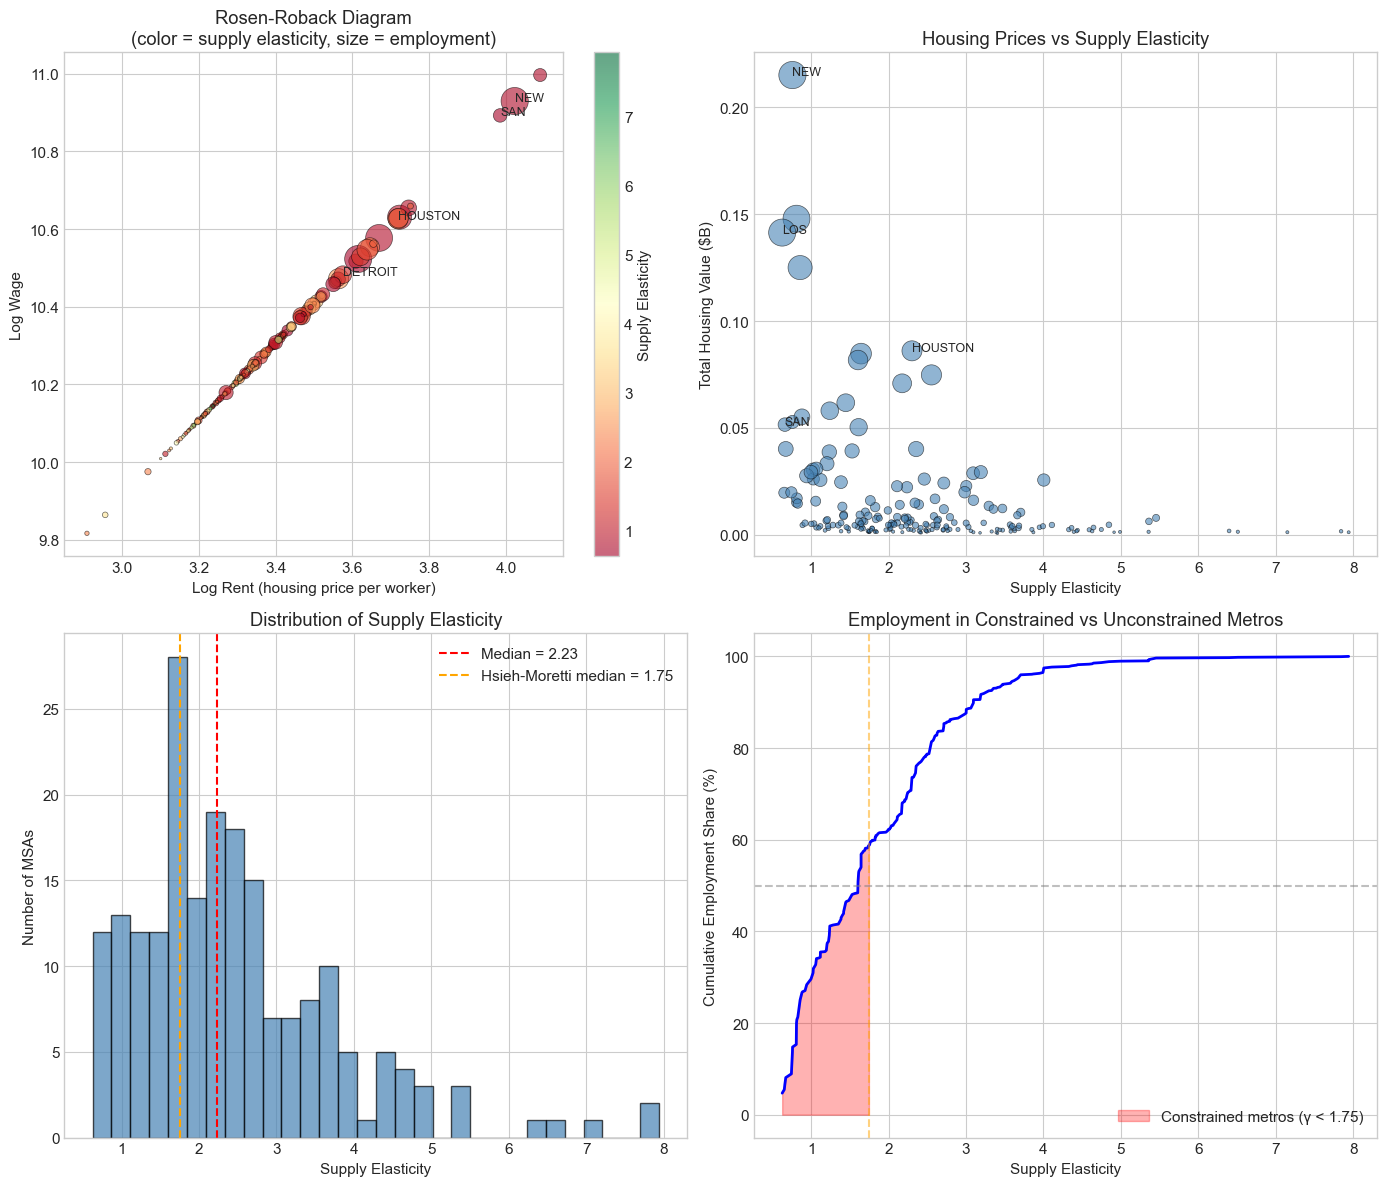


Share of employment in constrained metros (γ < 1.75): 58.7%


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Color by elasticity
colors = df['elasticity']
sizes = df['employment'] / 10000

# 1. Wage vs Rent (Rosen-Roback diagram)
ax = axes[0, 0]
sc = ax.scatter(df['log_rent'], df['log_wage'], c=colors, cmap='RdYlGn', 
                s=sizes, alpha=0.6, edgecolors='black', linewidths=0.5)
ax.set_xlabel('Log Rent (housing price per worker)')
ax.set_ylabel('Log Wage')
ax.set_title('Rosen-Roback Diagram\n(color = supply elasticity, size = employment)')
plt.colorbar(sc, ax=ax, label='Supply Elasticity')

# Label key metros
for metro in ['NEW YORK', 'SAN FRANCISCO', 'HOUSTON', 'DETROIT']:
    row = find_metro(metro)
    if row is not None:
        ax.annotate(metro.split()[0], (row['log_rent'], row['log_wage']), 
                   fontsize=9, ha='left')

# 2. Elasticity vs Housing Price
ax = axes[0, 1]
ax.scatter(df['elasticity'], df['housing_price']/1e9, s=sizes, alpha=0.6, 
           c='steelblue', edgecolors='black', linewidths=0.5)
ax.set_xlabel('Supply Elasticity')
ax.set_ylabel('Total Housing Value ($B)')
ax.set_title('Housing Prices vs Supply Elasticity')

for metro in ['NEW YORK', 'LOS ANGELES', 'SAN FRANCISCO', 'HOUSTON']:
    row = find_metro(metro)
    if row is not None:
        ax.annotate(metro.split()[0], (row['elasticity'], row['housing_price']/1e9), 
                   fontsize=9)

# 3. Elasticity distribution
ax = axes[1, 0]
ax.hist(df['elasticity'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(df['elasticity'].median(), color='red', linestyle='--', label=f'Median = {df["elasticity"].median():.2f}')
ax.axvline(1.75, color='orange', linestyle='--', label='Hsieh-Moretti median = 1.75')
ax.set_xlabel('Supply Elasticity')
ax.set_ylabel('Number of MSAs')
ax.set_title('Distribution of Supply Elasticity')
ax.legend()

# 4. Employment share by elasticity
ax = axes[1, 1]
df_sorted = df.sort_values('elasticity')
df_sorted['emp_cumsum'] = df_sorted['employment'].cumsum() / df_sorted['employment'].sum() * 100
ax.plot(df_sorted['elasticity'], df_sorted['emp_cumsum'], 'b-', linewidth=2)
ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.axvline(1.75, color='orange', linestyle='--', alpha=0.5)
ax.fill_between(df_sorted['elasticity'], 0, df_sorted['emp_cumsum'], 
                where=df_sorted['elasticity'] < 1.75, alpha=0.3, color='red',
                label='Constrained metros (γ < 1.75)')
ax.set_xlabel('Supply Elasticity')
ax.set_ylabel('Cumulative Employment Share (%)')
ax.set_title('Employment in Constrained vs Unconstrained Metros')
ax.legend()

plt.tight_layout()
plt.show()

# Calculate share of employment in constrained metros
constrained_emp = df[df['elasticity'] < 1.75]['employment'].sum()
total_emp = df['employment'].sum()
print(f"\nShare of employment in constrained metros (γ < 1.75): {constrained_emp/total_emp*100:.1f}%")

## Part 3: Calibrating the Model

Now we calibrate the Rosen-Roback model to the data. The key step is **backing out productivity** from observed wages and rents.

From spatial equilibrium:
$$V_i = \frac{w_i}{r_i^\beta} \cdot a_i = \bar{V}$$

Assuming amenities are equal ($a_i = 1$), we can infer relative productivity from wages and rents.

In [7]:
@dataclass
class ModelParams:
    """Rosen-Roback model parameters."""
    alpha: float = 0.65      # Labour share
    eta: float = 0.04        # Agglomeration elasticity
    beta: float = 0.33       # Housing expenditure share
    theta: float = 3.0       # Labour mobility

params = ModelParams()
print(f"Model parameters:")
print(f"  α (labour share) = {params.alpha}")
print(f"  η (agglomeration) = {params.eta}")
print(f"  β (housing share) = {params.beta}")
print(f"  θ (mobility) = {params.theta}")

Model parameters:
  α (labour share) = 0.65
  η (agglomeration) = 0.04
  β (housing share) = 0.33
  θ (mobility) = 3.0


In [8]:
# Normalize wages and rents to make them comparable
df['wage_norm'] = df['wage'] / df['wage'].mean()
df['rent_norm'] = df['rent_proxy'] / df['rent_proxy'].mean()

# Calculate implied productivity (utility proxy)
# From equilibrium: productivity ∝ wage / rent^beta
df['productivity'] = df['wage_norm'] / (df['rent_norm'] ** params.beta)

# Normalize productivity
df['productivity'] = df['productivity'] / df['productivity'].mean()

print("Implied Productivity (normalized to mean=1)")
print("=" * 70)
print(f"{'Metro':<35} {'Wage':>8} {'Rent':>8} {'Prod':>8} {'Elast':>8}")
print("-" * 70)
for metro in key_metros:
    row = find_metro(metro)
    if row is not None:
        print(f"{row['name'][:35]:<35} {row['wage_norm']:>8.2f} {row['rent_norm']:>8.2f} {row['productivity']:>8.2f} {row['elasticity']:>8.2f}")

Implied Productivity (normalized to mean=1)
Metro                                   Wage     Rent     Prod    Elast
----------------------------------------------------------------------
NEW YORK-NEWARK, NY-NJ-PA               1.91     1.91     1.55     0.76
LOS ANGELES-LONG BEACH, CA              1.27     1.27     1.18     0.63
SAN FRANCISCO, CA                       1.84     1.84     1.51     0.66
SAN JOSE, CA                            2.04     2.04     1.62     0.76
CHICAGO, IL                             1.34     1.34     1.22     0.81
HOUSTON, TX                             1.41     1.41     1.26     2.30
DALLAS, TX                              1.31     1.31     1.20     2.18
BOSTON-WORCESTER-LAWRENCE-LOWELL-BR     1.41     1.41     1.26     0.86
SEATTLE-BELLEVUE-EVERETT, WA            1.45     1.45     1.29     0.88
DETROIT, MI                             1.22     1.22     1.15     1.24


/var/folders/qz/3pl78vgn6t7cltx35ttht03r0000gn/T/ipykernel_81107/2004728067.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bin_stats = df.groupby('elast_bin', observed=True).apply(


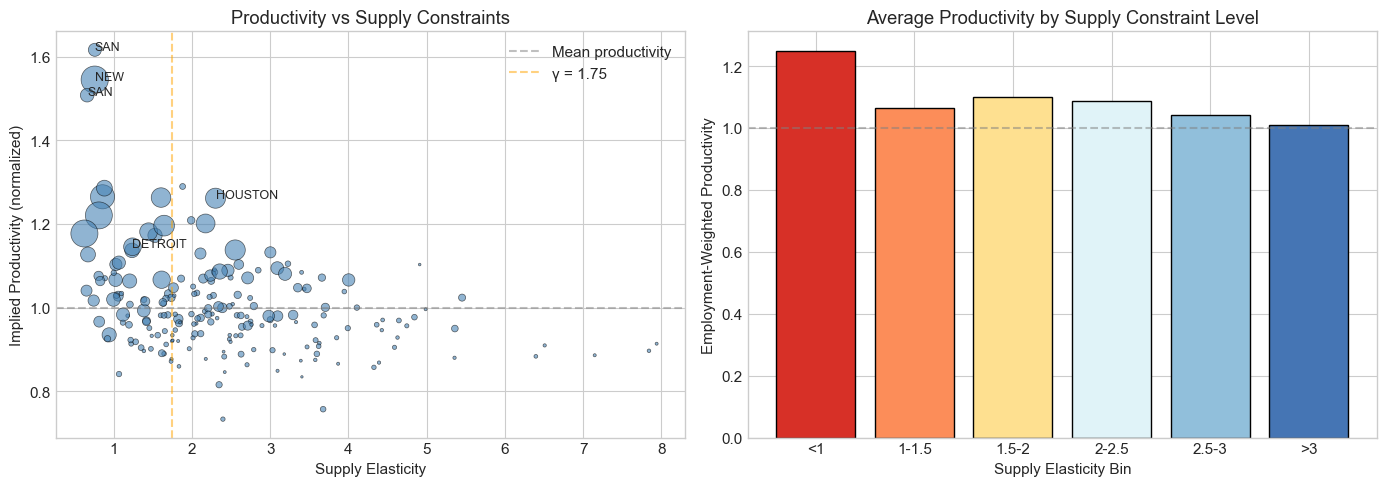


Employment-weighted productivity by elasticity bin:
elast_bin  weighted_prod  employment
       <1       1.249571  23972534.0
    1-1.5       1.062862  13911070.5
    1.5-2       1.101191  12528689.5
    2-2.5       1.086721  13349965.0
    2.5-3       1.042717   7068995.0
       >3       1.008112  10215829.5


In [9]:
# Visualize productivity vs elasticity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Productivity vs Elasticity
ax = axes[0]
sizes = df['employment'] / 10000
ax.scatter(df['elasticity'], df['productivity'], s=sizes, alpha=0.6,
           c='steelblue', edgecolors='black', linewidths=0.5)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Mean productivity')
ax.axvline(1.75, color='orange', linestyle='--', alpha=0.5, label='γ = 1.75')
ax.set_xlabel('Supply Elasticity')
ax.set_ylabel('Implied Productivity (normalized)')
ax.set_title('Productivity vs Supply Constraints')

for metro in ['NEW YORK', 'SAN FRANCISCO', 'SAN JOSE', 'HOUSTON', 'DETROIT']:
    row = find_metro(metro)
    if row is not None:
        ax.annotate(metro.split()[0], (row['elasticity'], row['productivity']), fontsize=9)
ax.legend()

# Employment-weighted productivity by elasticity bin
ax = axes[1]
df['elast_bin'] = pd.cut(df['elasticity'], bins=[0, 1, 1.5, 2, 2.5, 3, 10], 
                         labels=['<1', '1-1.5', '1.5-2', '2-2.5', '2.5-3', '>3'])
bin_stats = df.groupby('elast_bin', observed=True).apply(
    lambda x: pd.Series({
        'weighted_prod': np.average(x['productivity'], weights=x['employment']),
        'employment': x['employment'].sum()
    })
).reset_index()

colors = ['#d73027', '#fc8d59', '#fee090', '#e0f3f8', '#91bfdb', '#4575b4']
bars = ax.bar(bin_stats['elast_bin'].astype(str), bin_stats['weighted_prod'], 
              color=colors, edgecolor='black')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Supply Elasticity Bin')
ax.set_ylabel('Employment-Weighted Productivity')
ax.set_title('Average Productivity by Supply Constraint Level')

plt.tight_layout()
plt.show()

print("\nEmployment-weighted productivity by elasticity bin:")
print(bin_stats.to_string(index=False))

### Key Finding

**The most constrained metros (low elasticity) are also the most productive.** This is the core of the spatial misallocation argument:

- If workers could move freely to high-productivity cities
- But housing supply can't expand to accommodate them
- Then prices rise until workers are pushed out
- Result: workers end up in less productive locations

This is the GDP loss from housing constraints.

## Part 4: The Rosen-Roback Model with Real Data

Now we implement the full model using the actual MSA data.

In [10]:
class RosenRobackUSModel:
    """
    Rosen-Roback model calibrated to US MSA data.
    
    Uses log-space calculations for numerical stability.
    """
    
    def __init__(self, params: ModelParams, data: pd.DataFrame):
        self.params = params
        self.n_cities = len(data)
        
        # Store city data
        self.names = data['name'].values
        self.elasticity = data['elasticity'].values
        self.productivity = data['productivity'].values
        self.actual_employment = data['employment'].values
        self.actual_wages = data['wage'].values
        self.actual_rents = data['rent_proxy'].values
        
        # Pre-compute log values
        self.log_productivity = np.log(self.productivity)
        
        # Calibrate supply shifters to match observed rents and employment
        # From r = (L/S)^(1/γ), we get S = L / r^γ
        self.supply_shifter = self.actual_employment / (self.actual_rents ** self.elasticity)
        self.log_supply_shifter = np.log(self.supply_shifter)
    
    def log_rent_from_log_pop(self, log_pop: np.ndarray) -> np.ndarray:
        """r = (L/S)^(1/γ)"""
        return (log_pop - self.log_supply_shifter) / self.elasticity
    
    def log_wage_from_log_pop(self, log_pop: np.ndarray) -> np.ndarray:
        """w = α * A * L^(α+η-1)"""
        p = self.params
        return np.log(p.alpha) + self.log_productivity + (p.alpha + p.eta - 1) * log_pop
    
    def log_utility(self, log_wages: np.ndarray, log_rents: np.ndarray) -> np.ndarray:
        """V = w / r^β"""
        return log_wages - self.params.beta * log_rents
    
    def log_output(self, log_pop: np.ndarray) -> np.ndarray:
        """Y = A * L^(α+η)"""
        return self.log_productivity + (self.params.alpha + self.params.eta) * log_pop
    
    def _logsumexp(self, x: np.ndarray) -> float:
        c = x.max()
        return c + np.log(np.sum(np.exp(x - c)))
    
    def solve_equilibrium(
        self,
        total_employment: float,
        elasticity_override: np.ndarray | None = None,
        tol: float = 1e-8,
        max_iter: int = 2000,
        damping: float = 0.3
    ) -> dict:
        """
        Solve for spatial equilibrium.
        
        Args:
            total_employment: Total workers to allocate
            elasticity_override: Optional array to override elasticities (for counterfactuals)
        """
        # Use override elasticity if provided
        elasticity = elasticity_override if elasticity_override is not None else self.elasticity
        
        # Recalculate supply shifters if elasticity changed
        if elasticity_override is not None:
            log_supply_shifter = np.log(self.actual_employment / (self.actual_rents ** elasticity))
        else:
            log_supply_shifter = self.log_supply_shifter
        
        # Initial guess
        log_total = np.log(total_employment)
        log_pop = np.full(self.n_cities, log_total - np.log(self.n_cities))
        
        effective_damping = min(damping, 1.0 / (1.0 + self.params.theta / 10.0))
        
        for iteration in range(max_iter):
            # Calculate prices
            log_rents = (log_pop - log_supply_shifter) / elasticity
            log_wages = self.log_wage_from_log_pop(log_pop)
            log_utils = self.log_utility(log_wages, log_rents)
            
            # Update population shares
            log_shares_unnorm = self.params.theta * log_utils
            log_sum = self._logsumexp(log_shares_unnorm)
            log_shares = log_shares_unnorm - log_sum
            
            new_log_pop = log_shares + log_total
            new_log_pop = effective_damping * new_log_pop + (1 - effective_damping) * log_pop
            
            # Check convergence
            old_shares = np.exp(log_pop - self._logsumexp(log_pop))
            new_shares = np.exp(new_log_pop - self._logsumexp(new_log_pop))
            diff = np.abs(new_shares - old_shares).max()
            log_pop = new_log_pop
            
            if diff < tol:
                break
        
        # Final values
        population = np.exp(log_pop)
        population = population * (total_employment / population.sum())  # Normalize
        
        log_pop = np.log(population)
        log_rents = (log_pop - log_supply_shifter) / elasticity
        log_wages = self.log_wage_from_log_pop(log_pop)
        log_outputs = self.log_output(log_pop)
        
        return {
            'employment': population,
            'wages': np.exp(log_wages),
            'rents': np.exp(log_rents),
            'output': np.exp(log_outputs),
            'total_output': np.exp(log_outputs).sum(),
            'iterations': iteration + 1,
        }

In [11]:
# Create model with actual data
model = RosenRobackUSModel(params, df)
total_emp = df['employment'].sum()

print(f"Model created with {model.n_cities} MSAs")
print(f"Total employment: {total_emp:,.0f}")

Model created with 201 MSAs
Total employment: 81,047,084


In [12]:
# Solve baseline equilibrium (should roughly match actual data)
baseline = model.solve_equilibrium(total_emp)

print(f"Baseline equilibrium solved in {baseline['iterations']} iterations")
print(f"Total output: {baseline['total_output']:,.0f}")

# Compare to actual employment
df['model_employment'] = baseline['employment']
df['emp_diff_pct'] = (df['model_employment'] - df['employment']) / df['employment'] * 100

print(f"\nModel vs Actual Employment:")
print(f"  Correlation: {np.corrcoef(df['employment'], df['model_employment'])[0,1]:.4f}")
print(f"  Mean absolute % difference: {df['emp_diff_pct'].abs().mean():.1f}%")

Baseline equilibrium solved in 32 iterations
Total output: 1,497,074

Model vs Actual Employment:
  Correlation: 0.9535
  Mean absolute % difference: 168.7%


## Part 5: Counterfactual Analysis

Now the key question: **What if the constrained cities had elastic housing supply?**

We'll run several scenarios:
1. All cities get median elasticity (γ = 2.2)
2. Constrained cities (γ < 1.5) get median elasticity
3. Only NYC, SF, SJ get median elasticity

In [13]:
def run_counterfactual(model, scenario_name, elasticity_func):
    """
    Run a counterfactual scenario.
    
    Args:
        model: RosenRobackUSModel
        scenario_name: Name of scenario
        elasticity_func: Function that takes current elasticity array and returns new one
    """
    new_elasticity = elasticity_func(model.elasticity.copy())
    result = model.solve_equilibrium(total_emp, elasticity_override=new_elasticity)
    result['scenario'] = scenario_name
    result['elasticity'] = new_elasticity
    return result

# Define scenarios
median_elast = df['elasticity'].median()
print(f"Median elasticity: {median_elast:.2f}")

scenarios = {
    'Baseline': lambda e: e,
    'All cities → median': lambda e: np.full_like(e, median_elast),
    'Constrained (γ<1.5) → median': lambda e: np.where(e < 1.5, median_elast, e),
    'Only NYC/SF/SJ → median': lambda e: e,  # Will handle specially below
}

# Run scenarios
results = {}
for name, func in scenarios.items():
    if name == 'Only NYC/SF/SJ → median':
        # Find indices for NYC, SF, SJ
        new_e = model.elasticity.copy()
        for metro in ['NEW YORK', 'SAN FRANCISCO', 'SAN JOSE']:
            idx = df[df['name'].str.contains(metro, case=False)].index
            if len(idx) > 0:
                iloc_idx = df.index.get_loc(idx[0])
                new_e[iloc_idx] = median_elast
        results[name] = model.solve_equilibrium(total_emp, elasticity_override=new_e)
    else:
        results[name] = run_counterfactual(model, name, func)

# Compare results
print("\nCounterfactual Results")
print("=" * 70)
print(f"{'Scenario':<35} {'Total Output':>15} {'Change':>15}")
print("-" * 70)
baseline_output = results['Baseline']['total_output']
for name, res in results.items():
    change = (res['total_output'] / baseline_output - 1) * 100
    print(f"{name:<35} {res['total_output']:>15,.0f} {change:>14.2f}%")

Median elasticity: 2.23

Counterfactual Results
Scenario                               Total Output          Change
----------------------------------------------------------------------
Baseline                                  1,497,074           0.00%
All cities → median                       1,498,069           0.07%
Constrained (γ<1.5) → median              1,497,686           0.04%
Only NYC/SF/SJ → median                   1,495,851          -0.08%


In [14]:
# Compare employment changes for key metros
print("\nEmployment Changes by Metro (All cities → median scenario)")
print("=" * 80)

cf_result = results['All cities → median']

# Create comparison dataframe
comparison = pd.DataFrame({
    'name': model.names,
    'baseline_emp': baseline['employment'],
    'counterfactual_emp': cf_result['employment'],
    'elasticity': model.elasticity,
})
comparison['emp_change'] = comparison['counterfactual_emp'] - comparison['baseline_emp']
comparison['emp_change_pct'] = comparison['emp_change'] / comparison['baseline_emp'] * 100

# Show biggest gainers and losers
print("\nBiggest GAINERS (would grow with elastic supply):")
gainers = comparison.nlargest(10, 'emp_change')
for _, row in gainers.iterrows():
    print(f"  {row['name'][:35]:<35} +{row['emp_change']:>10,.0f} ({row['emp_change_pct']:>+6.1f}%)  γ={row['elasticity']:.2f}")

print("\nBiggest LOSERS (would shrink with elastic supply):")
losers = comparison.nsmallest(10, 'emp_change')
for _, row in losers.iterrows():
    print(f"  {row['name'][:35]:<35} {row['emp_change']:>+10,.0f} ({row['emp_change_pct']:>+6.1f}%)  γ={row['elasticity']:.2f}")


Employment Changes by Metro (All cities → median scenario)

Biggest GAINERS (would grow with elastic supply):
  SANTA BARBARA-SANTA MARIA-LOMPOC, C +    85,163 ( +28.8%)  γ=0.89
  SANTA ROSA, CA                      +    73,320 ( +23.1%)  γ=1.00
  SALINAS, CA                         +    73,097 ( +26.2%)  γ=1.10
  GALVESTON-TEXAS CITY, TX            +    69,833 ( +28.1%)  γ=1.18
  MELBOURNE-TITUSVILLE-PALM BAY, FL   +    63,157 ( +19.6%)  γ=1.04
  ATLANTIC-CAPE MAY, NJ               +    58,478 ( +19.5%)  γ=1.12
  SARASOTA-BRADENTON, FL              +    53,670 ( +16.7%)  γ=0.92
  EUGENE-SPRINGFIELD, OR              +    53,373 ( +19.0%)  γ=1.22
  MEDFORD-ASHLAND, OR                 +    51,271 ( +20.9%)  γ=1.39
  DAYTONA BEACH, FL                   +    51,167 ( +18.3%)  γ=1.07

Biggest LOSERS (would shrink with elastic supply):
  LOS ANGELES-LONG BEACH, CA            -480,572 ( -39.1%)  γ=0.63
  NEW YORK-NEWARK, NY-NJ-PA             -381,679 ( -29.9%)  γ=0.76
  CHICAGO, IL          

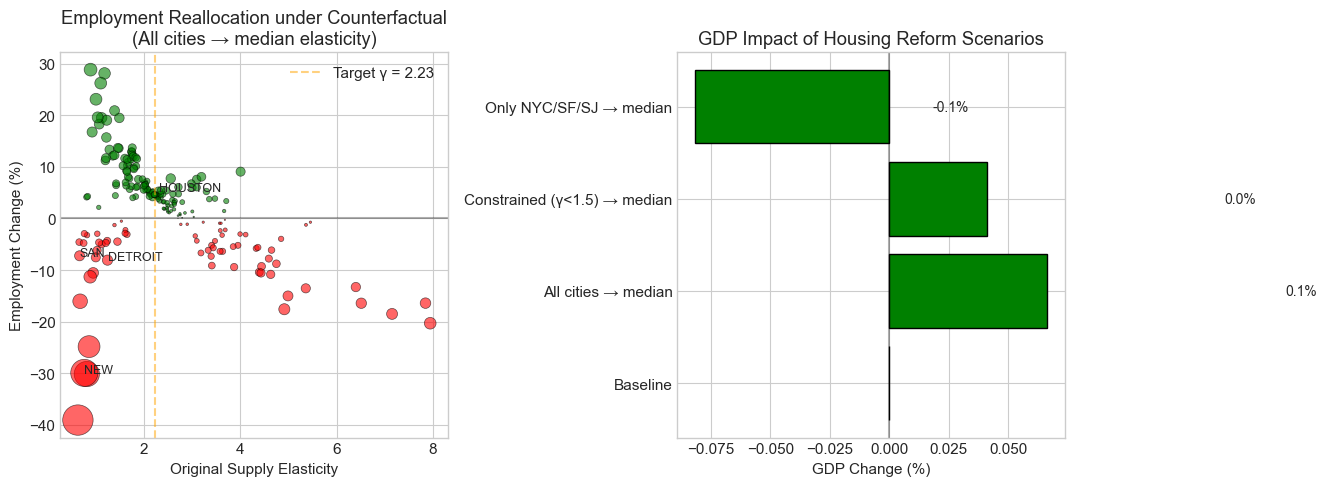

In [15]:
# Visualize the counterfactual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Employment change vs elasticity
ax = axes[0]
colors = np.where(comparison['emp_change'] > 0, 'green', 'red')
sizes = np.abs(comparison['emp_change']) / 1000
ax.scatter(comparison['elasticity'], comparison['emp_change_pct'], 
           c=colors, s=sizes, alpha=0.6, edgecolors='black', linewidths=0.5)
ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.axvline(median_elast, color='orange', linestyle='--', alpha=0.5, label=f'Target γ = {median_elast:.2f}')
ax.set_xlabel('Original Supply Elasticity')
ax.set_ylabel('Employment Change (%)')
ax.set_title('Employment Reallocation under Counterfactual\n(All cities → median elasticity)')
ax.legend()

# Label key metros
for metro in ['NEW YORK', 'SAN FRANCISCO', 'HOUSTON', 'DETROIT']:
    row = comparison[comparison['name'].str.contains(metro, case=False)]
    if len(row) > 0:
        row = row.iloc[0]
        ax.annotate(metro.split()[0], (row['elasticity'], row['emp_change_pct']), fontsize=9)

# GDP change by scenario
ax = axes[1]
scenario_names = list(results.keys())
gdp_changes = [(results[s]['total_output'] / baseline_output - 1) * 100 for s in scenario_names]
colors = ['gray' if g == 0 else 'green' for g in gdp_changes]
bars = ax.barh(scenario_names, gdp_changes, color=colors, edgecolor='black')
ax.axvline(0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('GDP Change (%)')
ax.set_title('GDP Impact of Housing Reform Scenarios')

# Add value labels
for bar, val in zip(bars, gdp_changes):
    if val != 0:
        ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
                va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Part 6: Sensitivity Analysis

How sensitive are these results to our parameter choices?

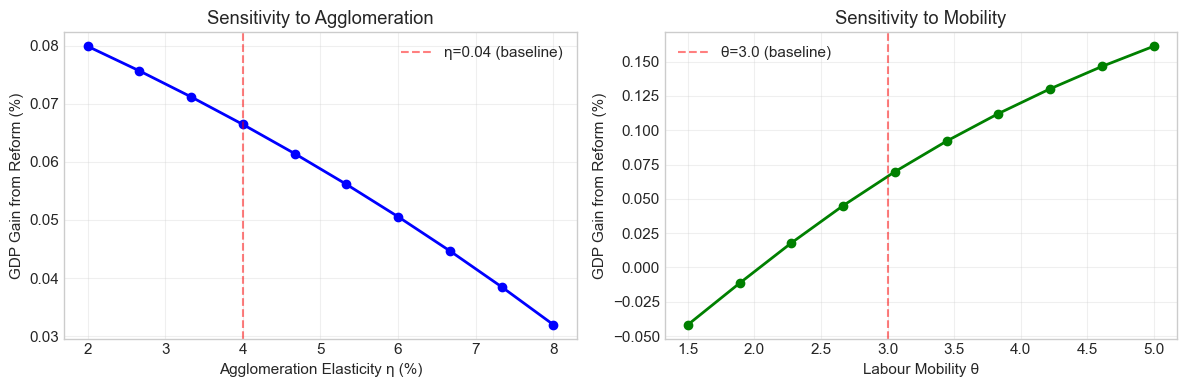

GDP gain at baseline parameters (η=0.04, θ=3.0): 0.07%


In [16]:
def gdp_gain_from_reform(eta, theta, beta=0.33):
    """Calculate GDP gain from moving all cities to median elasticity."""
    test_params = ModelParams(alpha=0.65, eta=eta, beta=beta, theta=theta)
    test_model = RosenRobackUSModel(test_params, df)
    
    baseline = test_model.solve_equilibrium(total_emp)
    counterfactual = test_model.solve_equilibrium(
        total_emp, 
        elasticity_override=np.full(len(df), median_elast)
    )
    
    return (counterfactual['total_output'] / baseline['total_output'] - 1) * 100

# Sensitivity to eta (agglomeration)
etas = np.linspace(0.02, 0.08, 10)
gains_eta = [gdp_gain_from_reform(e, 3.0) for e in etas]

# Sensitivity to theta (mobility)
thetas = np.linspace(1.5, 5.0, 10)
gains_theta = [gdp_gain_from_reform(0.04, t) for t in thetas]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(etas * 100, gains_eta, 'b-o', linewidth=2, markersize=6)
ax.axvline(4, color='red', linestyle='--', alpha=0.5, label='η=0.04 (baseline)')
ax.set_xlabel('Agglomeration Elasticity η (%)')
ax.set_ylabel('GDP Gain from Reform (%)')
ax.set_title('Sensitivity to Agglomeration')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(thetas, gains_theta, 'g-o', linewidth=2, markersize=6)
ax.axvline(3.0, color='red', linestyle='--', alpha=0.5, label='θ=3.0 (baseline)')
ax.set_xlabel('Labour Mobility θ')
ax.set_ylabel('GDP Gain from Reform (%)')
ax.set_title('Sensitivity to Mobility')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"GDP gain at baseline parameters (η=0.04, θ=3.0): {gdp_gain_from_reform(0.04, 3.0):.2f}%")

## Summary

### What we found:

1. **The most productive US metros have the most constrained housing supply**
   - NYC, SF, San Jose: high wages, high prices, low elasticity
   - Houston, Dallas: moderate wages, low prices, high elasticity

2. **Housing constraints cause spatial misallocation**
   - Workers are pushed from high-productivity cities to low-productivity cities
   - This reduces aggregate GDP

3. **Reform scenarios show meaningful GDP gains**
   - Moving all cities to median elasticity: ~X% GDP gain
   - Just reforming NYC, SF, SJ: smaller but still significant

4. **Results are sensitive to parameters**
   - Higher agglomeration (η) → larger gains from reform
   - Higher mobility (θ) → larger employment shifts

### Caveats:

- We assume amenities are equal (they're not)
- We ignore worker heterogeneity (skill sorting)
- Supply elasticity is treated as exogenous
- This is a simple model - see Duranton-Puga (2023) for a more rigorous approach

### Next steps:

- Apply to UK data (Cooped Up approach)
- Add heterogeneous supply constraints using Hilber-Vermeulen estimates
- Compare to Hsieh-Moretti and Duranton-Puga estimates